# Avance Fase 3 · Semana 2
## Núcleo algorítmico, programación orientada a objetos y eficiencia en ENSSEX

**Universidad Andrés Bello · MCDI500 · Programación para la Ciencia de Datos**  
**Grupo 9:** Guillermo Osorio Zamora y Karla Patricia Pizarro Correa  
**Sumativa 2 · Septiembre de 2026**

Integramos las reglas verificadas de F2 en componentes reutilizables de F3 y
comprobamos que la reorganización conserva los resultados. Documentamos las
decisiones de preparación, el diseño de clases, las pruebas y dos comparaciones
de eficiencia sobre nuestro conjunto ENSSEX 2022–2023.

**Alcance:** preparación y verificación para un análisis descriptivo de la muestra.
Este cuaderno no estima efectos causales ni desarrolla un modelo predictivo.
El informe de la Sumativa 2 se redacta por separado a partir de esta evidencia.

### Contenido
1. [Problema y criterios de evaluación](#problema)
2. [Ejecución reproducible y procedencia](#entorno)
3. [Evolución desde F2 y arquitectura](#arquitectura)
4. [POO y ejemplo verificable](#poo)
5. [Preparación completa y resultados intermedios](#preparacion)
6. [Faltantes, extremos y decisiones](#decisiones)
7. [Equivalencia funcional con F2](#equivalencia)
8. [Validación normal, límite y errores](#pruebas)
9. [Dos algoritmos para la diferencia de edad](#algoritmos)
10. [Protocolo de medición](#protocolo)
11. [Tiempo, memoria y complejidad](#complejidad)
12. [Lectura completa y por columnas del SAV](#lectura)
13. [Exportación, relectura y contrato de entrega](#exportacion)
14. [Verificación final y trazabilidad](#cierre)
15. [Referencias](#referencias)

<a id="problema"></a>
## 1. Problema y criterios de evaluación

**Pregunta:** ¿Cómo varían la valoración de la vida sexual y el bienestar mental
o emocional percibido según el grado de dependencia económica de la pareja
entre las personas encuestadas en ENSSEX 2022–2023 que conviven con ella?

Conservamos tres variables centrales: `p93` (dependencia económica), `i_6_p9`
(valoración de la vida sexual) e `i_2_p9` (bienestar mental o emocional percibido).
Las dos valoraciones se estudian por separado. La dependencia económica no
equivale a ingreso ni a estrés financiero; las valoraciones no son diagnósticos.

La revisión de Guan et al. (2022) sintetiza asociaciones entre estrés financiero
y depresión en estudios observacionales. Respalda la relevancia de estudiar
condiciones económicas y bienestar, pero sus variables y poblaciones difieren
de las nuestras. No trasladamos sus resultados a ENSSEX ni suponemos causalidad.
La información preparada puede apoyar preguntas de investigación y discusiones
de profesionales de bienestar y salud; no fundamenta decisiones clínicas individuales.

Trabajamos sin ponderadores ni estimación del diseño muestral: los resultados
describen la muestra seleccionada, no prevalencias nacionales. Los denominadores
se muestran por comparación para no ocultar las respuestas ausentes.

| Criterio de la rúbrica | Evidencia en este cuaderno |
|---|---|
| Diseño funcional y arquitectura | Secciones 3–4: responsabilidades, contratos, herencia y composición |
| Preprocesamiento | Secciones 5–6: selección, códigos, tipos, ausencias y derivada |
| Validación técnica | Secciones 7–8 y 13–14: equivalencia, pruebas y relectura |
| Eficiencia y optimización | Secciones 9–12: alternativas, repeticiones, memoria y análisis de costos |
| Diseño estructurado | División funcional, flujo explícito y reutilización de módulos |
| Programación orientada a objetos | Clase base, hijas, estado protegido y llamadas polimórficas |
| Documentación de arquitectura | Diagramas, fragmentos del código real, decisiones y referencias |
| Notebook ejecutado y documentado | Salidas intermedias y finales, comprobaciones y versiones |
| Repositorio y trazabilidad | Sección 14: evolución; la incorporación mediante PR y actualización del README se verifican aparte |
| Portada, índice y aspectos formales | Identificación e índice aquí; el informe institucional y su revisión formal son entregables separados |

La guía y los ejemplos docentes orientan nuestra adaptación: funciones pequeñas,
clases con responsabilidades concretas, igualdad antes de medir y evidencia
visible (Universidad Andrés Bello, s. f.-a, s. f.-b, s. f.-c).

<a id="entorno"></a>
## 2. Ejecución reproducible y procedencia

Ubicación prevista: `F3/notebooks/F3_Nucleo_algoritmico_ENSSEX.ipynb`.
Desde la raíz del proyecto, con el entorno del proyecto activo, iniciar
`jupyter lab`, abrir este cuaderno, seleccionar el kernel del entorno y ejecutar
**Restart Kernel and Run All Cells**. No se requiere conexión a internet durante
la ejecución; los enlaces son bibliográficos.

Requisitos: dependencias de `requirements.txt`, módulos de F2 y F3 integrados
hasta el PR #10, esquema vigente, evidencia de conversión y originales locales
en `data/raw`. Los originales no se descargan automáticamente ni se reemplazan.
Si falta un archivo, la ejecución se detiene con una indicación de su ruta relativa.

Las mediciones se ejecutan de nuevo: los tiempos pueden cambiar entre equipos.
La exportación escribe solamente productos F3. En una repetición completa,
si esos productos ya existen, se releen y comparan; no se sobrescriben. Las
pruebas de exportación usan destinos temporales independientes.

In [1]:
from pathlib import Path
import sys
import os
import json
import platform
import inspect
import subprocess
from datetime import datetime, timezone
from importlib.metadata import version

sys.dont_write_bytecode = True
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Code

# Permite ejecutar desde la raíz o desde F3/notebooks, sin rutas personales.
RAIZ = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / 'F3/src/pipeline_enssex.py').is_file()
             and (p / 'F2/docs/esquema_variables_F2.json').is_file()), None)
if RAIZ is None:
    raise FileNotFoundError('Abra el cuaderno dentro de F3/notebooks del proyecto ENSSEX.')
for carpeta in ('F2/src', 'F3/src', 'F3/benchmarks'):
    ruta = str(RAIZ / carpeta)
    if ruta not in sys.path:
        sys.path.insert(0, ruta)

import preparar_enssex as prep
from transformadores import Transformador, LimpiadorCodigos, TipificadorCategorias
from faltantes import TratamientoFaltantes, ESTRATEGIAS, conservar_faltantes, mediana_por_dependencia
from pipeline_enssex import PipelineENSSEX
from diferencia_edad import diferencia_con_bucle, diferencia_por_columnas
from exportacion_enssex import exportar_resultados_f3, leer_resultados_f3, ARCHIVOS, MANIFIESTO
from medir_diferencia_edad import ejecutar as medir_diferencia
from medir_lectura_sav import ejecutar as medir_lectura

SEMILLA = 42
REPETICIONES = 5
EJECUCIONES_ALGORITMO = 5
EJECUCIONES_LECTURA = 1
TAMANOS = (1000, 5000, 8579, 20000, 50000)
INICIO_UTC = datetime.now(timezone.utc).isoformat()
SALIDA_F3 = RAIZ / 'F3/data/processed'
paquetes = ('pandas', 'numpy', 'matplotlib', 'pyreadstat', 'ipykernel', 'jupyterlab')
entorno = {'python': platform.python_version(), 'sistema': platform.system(),
           'arquitectura': platform.machine(), **{p: version(p) for p in paquetes}}
display(pd.Series(entorno, name='versión / entorno').to_frame())
print('Semilla:', SEMILLA, '| Inicio UTC:', INICIO_UTC)

,versión / entorno
python,3.13.15
sistema,Windows
arquitectura,AMD64
pandas,3.0.5
numpy,2.5.3
matplotlib,3.11.2
pyreadstat,1.3.6
ipykernel,7.3.0
jupyterlab,4.6.3


Semilla: 42 | Inicio UTC: 2026-09-27T14:46:37.149778+00:00


In [2]:
ruta_esquema = RAIZ / 'F2/docs/esquema_variables_F2.json'
ruta_evidencia = RAIZ / 'docs/datos/verificacion_conversion_enssex.json'
esquema = json.loads(ruta_esquema.read_text(encoding='utf-8'))
evidencia_fuente = json.loads(ruta_evidencia.read_text(encoding='utf-8'))
ruta_csv = RAIZ / 'data/raw' / evidencia_fuente['csv_file']
ruta_sav = RAIZ / 'data/raw' / evidencia_fuente['source_file']
for ruta in (ruta_csv, ruta_sav):
    if not ruta.is_file():
        raise FileNotFoundError(f'Falta el original local: {ruta.relative_to(RAIZ)}')
assert prep.sha256_archivo(ruta_csv) == evidencia_fuente['csv_sha256']
assert prep.sha256_archivo(ruta_sav) == evidencia_fuente['source_sha256']

# Registramos los archivos protegidos antes de cualquier operación.
protegidos = [ruta_csv, ruta_sav, ruta_esquema, ruta_evidencia]
protegidos += sorted((RAIZ / 'F2/data/processed').glob('*.csv'))
protegidos += sorted((RAIZ / 'F2/src').glob('*.py'))
protegidos += sorted((RAIZ / 'F3/src').glob('*.py'))
protegidos += sorted((RAIZ / 'F3/tests').glob('*.py'))
protegidos += sorted((RAIZ / 'F3/benchmarks').glob('*.py'))
huellas_antes = {str(p.relative_to(RAIZ)): prep.sha256_archivo(p) for p in protegidos}
base = prep.cargar_base(ruta_csv, evidencia_fuente, esquema)
assert base.shape == (20392, 1126)
huella_base = pd.util.hash_pandas_object(base, index=True).copy()
tipos_base = base.dtypes.copy()
columnas_base = base.columns.copy()
display(pd.DataFrame([
    {'archivo': ruta_csv.name, 'SHA-256 exacto': evidencia_fuente['csv_sha256']},
    {'archivo': ruta_sav.name, 'SHA-256 exacto': evidencia_fuente['source_sha256']},
    {'archivo': ruta_esquema.name + ' (LF normalizado)',
     'SHA-256 exacto': prep.sha256_codigo(ruta_esquema)},
]))
print(f'Base original verificada: {base.shape[0]:,} personas y {base.shape[1]:,} columnas.')

,archivo,SHA-256 exacto
0,20241205_enssex_desde_sav.csv,75393ce321f5151fbfd7846034158aabcbe448e82c76fa...
1,20241205_enssex_data.sav,0f4218b9553600dfd44e6b1f78d376b040a0e6f0d85445...
2,esquema_variables_F2.json (LF normalizado),ba07debf0ff880bac775c64584a2fcb1c172ff7f88a13a...


Base original verificada: 20,392 personas y 1,126 columnas.


La huella de los datos se calcula sobre bytes exactos. Para código y esquema
usamos además huellas con finales de línea normalizados a LF: el PR #2 resolvió
la diferencia entre LF y CRLF sin relajar la verificación del original. Una
huella detecta diferencias respecto de la referencia, no certifica por sí sola
la autenticidad de una fuente.

<a id="arquitectura"></a>
## 3. Evolución desde F2 y arquitectura

F2 ya separaba preparación, visualización y documentación en módulos. F3
reutiliza esas reglas; agrega control de estado mediante clases, estrategias
intercambiables, coordinación, exportación verificable y experimentos de
rendimiento. La resta por columnas ya existía en F2: el bucle se incorpora como
alternativa didáctica para compararla, sin atribuirle una mejora inexistente.

```text
CSV original + evidencia + esquema
    → carga verificada (F2)
    → selección p81=1 y p83=1; 19 columnas
    → LimpiadorCodigos
    → TratamientoFaltantes: conservar en las tres centrales
    → TipificadorCategorias
    → diferencia de edad + matriz nominal + 130 validaciones
    → productos en memoria
    → exportación F3 + manifiesto → relectura exacta

Ramas de evaluación independientes:
    tabla limpia → 14 escenarios de faltantes (no alimentan el producto)
    edades limpias → dos algoritmos → igualdad → mediciones
    SAV original → dos formas de lectura → igualdad → mediciones
```

| Componente | Responsabilidad y contrato |
|---|---|
| `F2/src/preparar_enssex.py` | Reglas de dominio, selección, limpieza, derivada y referencia funcional |
| `F3/src/transformadores.py` | Validar, ajustar y transformar una copia; categorías y limpieza |
| `F3/src/faltantes.py` | Aplicar una estrategia a una variable central y devolver evidencia |
| `F3/src/pipeline_enssex.py` | Coordinar etapas; devolver productos e intermedios; no escribir archivos |
| `F3/src/exportacion_enssex.py` | Serializar y recuperar productos conservando sus tipos y categorías |
| `F3/src/diferencia_edad.py` | Dos implementaciones con el mismo contrato de salida |
| `F3/src/medicion_*.py` y `F3/benchmarks/` | Medición reproducible separada de preparación y exportación |
| `F3/tests/` | Casos conocidos, límites, errores y equivalencia sobre datos reales |
| Este notebook | Coordinar la demostración, explicar decisiones y mostrar evidencia |

La cohesión proviene de asignar una tarea a cada componente. El esquema se pasa
explícitamente, reduciendo reglas duplicadas. El acoplamiento con F2 es intencional:
mantiene una única definición de las transformaciones y exige preservar sus
contratos. Las rutas de importación están centralizadas en la configuración.

**División funcional:** el flujo tiene etapas tabulares conocidas, sin árboles ni
subproblemas anidados que requieran recursividad. Utilizamos funciones y composición
de objetos, la alternativa permitida en las instrucciones. Añadir una llamada
recursiva artificial no ayudaría a esta preparación (Universidad Andrés Bello,
s. f.-a, s. f.-b).

<a id="poo"></a>
## 4. POO y ejemplo verificable

```text
Transformador
  ├── LimpiadorCodigos
  ├── TipificadorCategorias
  └── TratamientoFaltantes ── recibe una función de estrategia

PipelineENSSEX ── compone instancias de las tres clases hijas
```

- **Herencia:** las hijas reutilizan `ajustar()` y `transformar()` de la base y
  especializan `_aplicar()` o la validación cuando corresponde.
- **Polimorfismo:** el coordinador llama `etapa.ajustar(tabla).transformar(tabla)`
  sin escribir una transformación diferente para cada tipo de objeto.
- **Encapsulamiento:** `_esquema`, `_ajustado` y `_resumen` son atributos internos
  por convención de Python. Las copias defensivas protegen configuración y
  resultados; un guion bajo no impide técnicamente el acceso externo.
- **Composición:** `PipelineENSSEX` utiliza transformadores; no hereda de ellos
  porque entrega varias tablas y evidencia, en lugar de una sola transformación.
- **Strategy:** `TratamientoFaltantes` recibe una función que decide el tratamiento.
  Cambiarla no requiere reescribir la validación ni el resumen. Las cinco funciones
  cumplen la misma firma; es una adaptación sencilla del patrón de clase.

Aquí `ajustar()` comprueba entradas y habilita el objeto. No aprende parámetros
de entrenamiento. Los escenarios son descriptivos sobre la misma muestra:
no son estimadores para transformar un conjunto de prueba. No dividimos los datos
en entrenamiento y prueba porque no ajustamos un modelo predictivo. Así adaptamos
la práctica de clases y el ejemplo de pipeline a nuestro objetivo
(Universidad Andrés Bello, s. f.-b, s. f.-c).

El siguiente fragmento se obtiene del módulo que realmente se ejecuta; no es
una segunda implementación mantenida dentro del cuaderno.

In [3]:
display(Code(inspect.getsource(Transformador.transformar), language='python'))
display(Code(inspect.getsource(TipificadorCategorias._aplicar), language='python'))
display(pd.DataFrame([
    {'clase': cls.__name__, 'clase base': cls.__bases__[0].__name__,
     'módulo': cls.__module__}
    for cls in (Transformador, LimpiadorCodigos, TipificadorCategorias,
                TratamientoFaltantes, PipelineENSSEX)
]))

def transformar(self, tabla):
        """Valida también la nueva tabla y delega el trabajo sobre una copia."""
        if not self._ajustado:
            raise RuntimeError("Llamar a ajustar() antes de transformar().")
        self._validar_entrada(tabla)
        return self._aplicar(tabla.copy(deep=True))

def _aplicar(self, tabla):
        # Comprobamos los valores antes de convertirlos a categorías.
        for variable in self._esquema["variables"]:
            categorias = variable["categorias"]

            if categorias:
                nombre = variable["nombre"]
                presentes = tabla[nombre].dropna()

                if not presentes.isin(categorias).all():
                    raise ValueError(
                        f"Categoría no documentada en {nombre}."
                    )

        return tipificar_categorias(tabla, self._esquema)

,clase,clase base,módulo
0,Transformador,object,transformadores
1,LimpiadorCodigos,Transformador,transformadores
2,TipificadorCategorias,Transformador,transformadores
3,TratamientoFaltantes,Transformador,faltantes
4,PipelineENSSEX,object,pipeline_enssex


In [4]:
esquema_ejemplo = {'variables': [
    {'nombre': 'nivel', 'categorias': [1, 2, 3], 'ordenada': True},
    {'nombre': 'grupo', 'categorias': [10, 20], 'ordenada': False},
]}
ejemplo = pd.DataFrame({'nivel': [2, None, 1], 'grupo': [20, 10, None]})
respaldo_ejemplo = ejemplo.copy(deep=True)
tipificador_ejemplo = TipificadorCategorias(esquema_ejemplo)

def comprobar_error(tipo, operacion):
    """Confirma el error esperado y falla si la operación se acepta."""
    try:
        operacion()
    except tipo as error:
        print(f'OK: {tipo.__name__} esperado: {error}')
    else:
        raise AssertionError(f'No se produjo {tipo.__name__}.')

comprobar_error(RuntimeError, lambda: tipificador_ejemplo.transformar(ejemplo))
tipificado_ejemplo = tipificador_ejemplo.ajustar(ejemplo).transformar(ejemplo)
assert tipificado_ejemplo['nivel'].cat.ordered
assert not tipificado_ejemplo['grupo'].cat.ordered
assert tipificado_ejemplo['nivel'].cat.categories.tolist() == [1, 2, 3]
pd.testing.assert_frame_equal(ejemplo, respaldo_ejemplo, check_exact=True)
invalido = ejemplo.copy(deep=True)
invalido.loc[0, 'nivel'] = 7
comprobar_error(ValueError, lambda: tipificador_ejemplo.transformar(invalido))
display(tipificado_ejemplo)
print('OK: categorías, orden, ausencias y entrada conservados.')

OK: RuntimeError esperado: Llamar a ajustar() antes de transformar().
OK: ValueError esperado: Categoría no documentada en nivel.


,nivel,grupo
0,2,20
1,NaN,10
2,1,NaN


OK: categorías, orden, ausencias y entrada conservados.


<a id="preparacion"></a>
## 5. Preparación completa y resultados intermedios

La selección exige convivencia declarada en `p81` y `p83`. Reducimos filas y
columnas antes de las transformaciones. El identificador se mantiene como texto
para conservar su significado; no se utiliza como predictor. Los códigos de no
respuesta se convierten en faltantes según cada variable, sin asumir que cero o
un mismo código tienen idéntico significado en toda la base.

Pandas permite categorías con orden explícito y enteros que admiten valores
ausentes; estas representaciones evitan sustituir ausencias por números
inventados (The pandas development team, s. f.-a, s. f.-b).

In [5]:
pipeline = PipelineENSSEX(esquema)
resultados = pipeline.ejecutar(base)
seleccion = resultados['seleccion']
limpia = resultados['limpia']
principal = resultados['principal']
nominales = resultados['nominales']
assert seleccion.shape == (8579, 19)
assert principal.shape == (8579, 20)
assert nominales.shape == (8579, 65)
assert 'anios_convivencia_aprox' not in principal
display(resultados['flujo_seleccion'])
display(resultados['resumen_limpieza'])
display(resultados['resumen_faltantes'])
display(resultados['disponibilidad'])
recodificados = int(resultados['resumen_limpieza']['NS_NR_a_faltante'].sum())
assert recodificados == 883
assert resultados['resumen_faltantes']['imputados'].sum() == 0
assert resultados['resumen_faltantes']['filas_excluidas'].sum() == 0
print(f'OK: {recodificados} códigos de no respuesta recodificados; sin imputaciones.')

,etapa,filas,excluidas_en_paso
0,Base completa,20392,0
1,Tiene pareja (p81=1),11239,9153
2,Además convive (p83=1),8579,2660


,variable,vacios_originales,NS_NR_a_faltante,faltantes_despues,filas_eliminadas
0,p93,0,77,77,0
1,i_6_p9,0,105,105,0
2,i_2_p9,0,11,11,0
3,p4,0,0,0,0
4,p1,0,0,0,0
5,p3,0,3,3,0
6,p5,0,0,0,0
7,region,0,0,0,0
8,p7,0,5,5,0
9,p92,0,170,170,0


,variable,alternativa,filas_entrada,filas,filas_excluidas,elegibles,vacios_originales_protegidos,faltantes,imputados,valores_fraccionarios,fuera_de_categorias,varianza_codigos,cambio_varianza_pct
0,p93,Conservar faltantes,8579,8579,0,77,0,77,0,0,0,0.704055,0.0
1,i_6_p9,Conservar faltantes,8579,8579,0,105,0,105,0,0,0,2.422101,0.0
2,i_2_p9,Conservar faltantes,8579,8579,0,11,0,11,0,0,0,1.599574,0.0


,criterio,disponibles,no_disponibles
0,Convivientes conservados,8579,0
1,Dependencia y valoración de vida sexual,8399,180
2,Dependencia y bienestar emocional,8491,88
3,Tres centrales completas,8392,187
4,Todas las 19 originales completas,7825,754


OK: 883 códigos de no respuesta recodificados; sin imputaciones.


In [6]:
# Diccionario derivado del esquema y de los tipos que realmente resultaron.
reglas = {v['nombre']: v for v in esquema['variables']}
diccionario = pd.DataFrame([
    {'variable': nombre,
     'significado': reglas[nombre]['descripcion'] if nombre in reglas
                    else 'Edad de la persona menos edad de la pareja (p4 - p91)',
     'tipo_salida': str(principal[nombre].dtype),
     'faltantes': int(principal[nombre].isna().sum()),
     'categorias': str(reglas[nombre]['categorias']) if nombre in reglas else '',
     'ordenada': reglas[nombre]['ordenada'] if nombre in reglas else False}
    for nombre in principal.columns
])
with pd.option_context('display.max_rows', 25, 'display.max_colwidth', 80):
    display(diccionario)
# Solo mostramos campos de preparación; no imprimimos folios de participantes.
display(principal[['p93', 'i_6_p9', 'i_2_p9', 'p4', 'p91', 'diferencia_edad_pareja']].head())
print('Matriz nominal:', nominales.shape, '(folio y 64 indicadores).')

,variable,significado,tipo_salida,faltantes,categorias,ordenada
0,p93,¿Diría que usted depende económicamente de su pareja?,category,77,"[1, 2, 3]",True
1,i_6_p9,P9: valorar de 1 a 7 cómo se siente en distintos ámbitos. Ítem: «Con su vida...,category,105,"[1, 2, 3, 4, 5, 6, 7]",True
2,i_2_p9,P9: valorar de 1 a 7 cómo se siente en distintos ámbitos. Ítem: «Con su bien...,category,11,"[1, 2, 3, 4, 5, 6, 7]",True
3,p4,¿Qué edad tiene? (años).,Int64,0,[],False
4,p1,¿Cuál es su sexo asignado al nacer?,category,0,"[1, 2]",False
5,p3,¿Cuál es el género con el que usted se identifica?,category,3,"[1, 2, 3, 4, 5, 6]",False
6,p5,¿Cuál es su nivel educacional más alto alcanzado o su nivel educacional actual?,category,0,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]",False
7,region,Región registrada en la base; no es una pregunta numerada del cuestionario.,category,0,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]",False
8,p7,¿Cuál es su estado conyugal o civil actual?,category,5,"[1, 2, 3, 4, 5, 6, 7, 8]",False
9,p92,"Comparando con su pareja actual, el ingreso económico de usted es…",category,170,"[1, 2, 3, 4, 5, 6]",False


,p93,i_6_p9,i_2_p9,p4,p91,diferencia_edad_pareja
10,1,4,4,37,42,-5
12,3,6,3,35,35,0
13,3,5,3,28,30,-2
14,1,6,5,38,47,-9
15,3,7,7,23,23,0


Matriz nominal: (8579, 65) (folio y 64 indicadores).


<a id="decisiones"></a>
## 6. Faltantes, extremos y decisiones

Comparamos cinco estrategias: conservar, usar casos disponibles solo para un
cálculo, media global, mediana global y mediana por dependencia. Son 14 escenarios:
no imputamos `p93` agrupando por esa misma variable. Las simulaciones solo
reemplazan códigos explícitos de no respuesta; protegen los vacíos originales.
Sin grupo válido o sin observaciones donantes, la mediana de grupo deja la ausencia.

Las centrales son ordinales. Una media de sus códigos puede ser fraccionaria;
incluso una mediana válida no demuestra que sea la respuesta faltante. La
varianza de códigos se usa para describir el cambio mecánico de dispersión,
no como prueba de una escala de intervalos iguales. Conservamos las ausencias
en el producto principal y declaramos la disponibilidad de cada comparación.

In [7]:
respaldo_limpia = limpia.copy(deep=True)
escenarios = []
for nombre in esquema['centrales']:
    for estrategia in ESTRATEGIAS:
        if nombre == 'p93' and estrategia is mediana_por_dependencia:
            continue
        tratamiento = TratamientoFaltantes(esquema, nombre, estrategia, seleccion)
        escenario = tratamiento.ajustar(limpia).transformar(limpia)
        escenarios.append(tratamiento.resumen())
comparacion_faltantes = pd.concat(escenarios, ignore_index=True)
assert len(comparacion_faltantes) == 14
pd.testing.assert_frame_equal(limpia, respaldo_limpia, check_exact=True)
# Esta referencia verifica el resumen para esta muestra real.
referencia_faltantes = prep.comparar_imputaciones(limpia, esquema['centrales'])
columnas_comunes = referencia_faltantes.columns.tolist()
pd.testing.assert_frame_equal(comparacion_faltantes[columnas_comunes],
                              referencia_faltantes, check_exact=True)
with pd.option_context('display.max_columns', None, 'display.max_rows', 20):
    display(comparacion_faltantes.round(4))
print('OK: 14 escenarios equivalentes a F2; ninguno reemplaza el producto principal.')

,variable,alternativa,filas_entrada,filas,filas_excluidas,elegibles,vacios_originales_protegidos,faltantes,imputados,valores_fraccionarios,fuera_de_categorias,varianza_codigos,cambio_varianza_pct
0,p93,Conservar faltantes,8579,8579,0,77,0,77,0,0,0,0.7041,0.0000
1,p93,Eliminar solo para este cálculo,8579,8502,77,77,0,0,0,0,0,0.7041,0.0000
2,p93,Imputar media global,8579,8579,0,77,0,0,77,77,77,0.6977,-0.8975
3,p93,Imputar mediana global,8579,8579,0,77,0,0,77,0,0,0.7027,-0.1859
4,i_6_p9,Conservar faltantes,8579,8579,0,105,0,105,0,0,0,2.4221,0.0000
5,i_6_p9,Eliminar solo para este cálculo,8579,8474,105,105,0,0,0,0,0,2.4221,0.0000
6,i_6_p9,Imputar media global,8579,8579,0,105,0,0,105,105,105,2.3925,-1.2239
7,i_6_p9,Imputar mediana global,8579,8579,0,105,0,0,105,0,0,2.3940,-1.1582
8,i_6_p9,Imputar mediana por dependencia,8579,8579,0,105,0,2,103,0,0,2.3946,-1.1364
9,i_2_p9,Conservar faltantes,8579,8579,0,11,0,11,0,0,0,1.5996,0.0000


OK: 14 escenarios equivalentes a F2; ninguno reemplaza el producto principal.


In [8]:
display(prep.resumen_atipicos(principal, ['p4', 'p91', 'diferencia_edad_pareja']))
display(prep.diagnosticar_tiempo(seleccion))

,variable,n,min,Q1,mediana,Q3,max,limite_inferior,limite_superior,senalados_IQR
0,p4,8579,18.0,34.0,47.0,60.0,100.0,-5.0,99.0,1
1,p91,8579,18.0,35.0,48.0,61.0,100.0,-4.0,100.0,0
2,diferencia_edad_pareja,8579,-81.0,-4.0,-1.0,2.0,48.0,-13.0,11.0,502


,revision,registros
0,Fecha ausente,0
1,Texto de fecha no interpretable,0
2,Fecha fuera de 2022–2023,0
3,Si fecha fuera la referencia: inicio posterior...,0
4,Si fecha fuera la referencia: duración supera ...,0
5,Si fecha fuera la referencia: duración supera ...,8


**Decisiones a partir del dominio y del diagnóstico:**

| Aspecto | Tratamiento y razón |
|---|---|
| Extremos | La regla 1,5 IQR señala valores para revisión; no demuestra errores. Conservamos las edades válidas y diferencias grandes sin borrarlas ni winsorizarlas. |
| Duración de convivencia | No calculamos años a partir de `fecha` porque su referencia no está validada. Los diagnósticos temporales son hipótesis, no correcciones de fechas. Retiramos la columna vacía cuestionada en S1. |
| Categorías | Conservamos códigos documentados y su orden. Rechazamos categorías desconocidas antes de convertirlas, para que no se oculten como NA. |
| Matriz nominal | Codificación separada con indicadores de ausencia. No reemplaza la tabla principal ni convierte folios o filtros constantes en predictores. |
| Escalamiento | No aplicamos z-score ni min–max: no entrenamos un algoritmo sensible a distancias y necesitamos conservar años y categorías interpretables. Reconsiderar solo ante una necesidad analítica concreta posterior. |
| Normalización | Estandarizamos tipos, ausencias y serialización; esto no equivale a escalar numéricamente todas las variables. |
| Dependencia y valoraciones | Mantenemos sus significados separados y no inventamos un indicador compuesto de bienestar. |

Las reglas de ausencia y categorías se apoyan en el esquema, cuestionario y
diccionario documentados en F1–F2. La documentación de pandas sustenta la
implementación, no sustituye esa justificación de dominio.

<a id="equivalencia"></a>
## 7. Equivalencia funcional con F2

Reconstruimos la salida de F2 mediante sus funciones y la comparamos exactamente
con F3: valores, tipos, faltantes, orden, índice y categorías. Esta comparación
confirma que la reorganización conserva el comportamiento. Como F3 reutiliza
funciones de F2, complementamos esa evidencia con casos conocidos independientes
en las pruebas; la coincidencia entre ambas fases no prueba por sí sola que las
reglas científicas sean correctas.

In [9]:
seleccion_f2, flujo_f2 = prep.seleccionar_convivientes(base, esquema)
limpia_f2, resumen_f2 = prep.limpiar_codigos(seleccion_f2, esquema)
tipificada_f2 = prep.tipificar_categorias(limpia_f2, esquema)
principal_f2 = prep.construir_derivadas(tipificada_f2)
nominales_f2 = prep.codificar_nominales(principal_f2, esquema)
referencias_f2 = {'seleccion': seleccion_f2, 'flujo_seleccion': flujo_f2,
                 'limpia': limpia_f2, 'resumen_limpieza': resumen_f2,
                 'tipificada': tipificada_f2, 'principal': principal_f2,
                 'nominales': nominales_f2}
for nombre, referencia in referencias_f2.items():
    pd.testing.assert_frame_equal(resultados[nombre], referencia, check_exact=True)
validaciones = resultados['validaciones']
assert len(validaciones) == 130
assert validaciones['resultado'].eq('OK').all()
display(pd.DataFrame({'producto comparado': list(referencias_f2), 'igualdad exacta': 'OK'}))
with pd.option_context('display.max_rows', 140, 'display.max_colwidth', 100):
    display(validaciones)

,producto comparado,igualdad exacta
0,seleccion,OK
1,flujo_seleccion,OK
2,limpia,OK
3,resumen_limpieza,OK
4,tipificada,OK
5,principal,OK
6,nominales,OK


,comprobacion,resultado
0,Se conservan todas las personas seleccionadas y su orden,OK
1,19 columnas originales y una derivada calculada,OK
2,Folios presentes y únicos,OK
3,Filtros de pareja y convivencia,OK
4,Dominio y orden de p93,OK
5,Faltantes explicados y sin imputación en p93,OK
6,Respuestas sustantivas conservadas en p93,OK
7,Dominio y orden de i_6_p9,OK
8,Faltantes explicados y sin imputación en i_6_p9,OK
9,Respuestas sustantivas conservadas en i_6_p9,OK


<a id="pruebas"></a>
## 8. Validación normal, límite y errores

| Grupo | Ejemplos comprobados | Resultado esperado |
|---|---|---|
| Normal | Códigos conocidos, categorías, signo de la resta, productos y resúmenes | Valores y tipos esperados, entrada intacta |
| Límites | Una persona, ausencia de faltantes, todos faltantes, categorías sin observaciones, ceros iniciales en folios | Contrato conservado; ausencia explícita cuando corresponde |
| Vacío | Resta de series vacías y pipeline sin selección | La resta admite vacío; el pipeline lo rechaza porque no puede entregar una población seleccionada |
| Errores | Uso antes de ajustar, columnas duplicadas o ausentes, categoría desconocida, tipos inválidos | Excepción prevista; no aceptación silenciosa |
| Estado | Ajuste fallido, configuración externa modificada, copias de resultados | Estado inválido deshabilitado y recuperación mediante ajuste válido |
| Exportación | Sobrescritura, alteración del CSV, indicadores distintos de 0/1 | Rechazo y detección del problema |
| Mediciones | Alternativas no equivalentes o rastreo de memoria externo activo | No iniciar una medición inválida ni interferir con el rastreo ajeno |

Ejecutamos los siete scripts en procesos separados con el mismo intérprete del
kernel. Conservamos sus registros completos en las salidas siguientes. Los
errores esperados son parte de las pruebas y se capturan dentro de ellas; un
fallo real detiene el notebook. Los mensajes de alcance de cada script se
refieren a su componente, no a la cobertura total de este cuaderno.

In [10]:
scripts_prueba = [
    'validar_transformadores.py', 'validar_faltantes.py', 'validar_pipeline.py',
    'validar_exportacion.py', 'validar_medicion_lectura.py',
    'validar_diferencia_edad.py', 'validar_medicion_algoritmos.py',
]
entorno_pruebas = dict(os.environ, PYTHONDONTWRITEBYTECODE='1', PYTHONIOENCODING='utf-8')
registros_pruebas = []
for nombre in scripts_prueba:
    proceso = subprocess.run(
        [sys.executable, str(RAIZ / 'F3/tests' / nombre)], cwd=RAIZ,
        env=entorno_pruebas, capture_output=True, text=True, encoding='utf-8',
        timeout=300,
    )
    print(f'\n{nombre}\n{proceso.stdout}', end='')
    if proceso.stderr:
        print(proceso.stderr)
    if proceso.returncode != 0:
        raise RuntimeError(f'Falló {nombre}; revisar la salida anterior.')
    registros_pruebas.append({'script': nombre, 'resultado': 'OK',
                             'codigo_salida': proceso.returncode})
tabla_pruebas = pd.DataFrame(registros_pruebas)
display(tabla_pruebas)


validar_transformadores.py
OK: Impide transformar o consultar resultados antes de tiempo
OK: Caso normal: códigos, ausencias, tipos e índice correctos
OK: Las copias protegen la entrada y el resumen interno
OK: Cambiar el esquema externo no altera las reglas del objeto
OK: Límites: una fila, sin faltantes y todos faltantes
OK: Rechaza columnas ausentes o duplicadas, vacío, tipo y código inválidos
OK: Un ajuste fallido deshabilita el objeto; un ajuste válido permite recuperarlo
OK: La clase base exige que la clase hija aporte la operación
OK: categorías ordinales y nominales correctas.
OK: valores, faltantes y entrada conservados.
OK: rechaza categorías desconocidas y uso antes de ajustar.
OK: selección real de 8,579 personas y 19 columnas.
OK: valores, ausencias, tipos, orden y resumen idénticos a la limpieza de F2.
OK: tipificación real de 8.579 personas y 19 columnas idéntica a F2.
OK: categorías y orden coinciden con el esquema; códigos, faltantes y columnas no categóricas conserva

,script,resultado,codigo_salida
0,validar_transformadores.py,OK,0
1,validar_faltantes.py,OK,0
2,validar_pipeline.py,OK,0
3,validar_exportacion.py,OK,0
4,validar_medicion_lectura.py,OK,0
5,validar_diferencia_edad.py,OK,0
6,validar_medicion_algoritmos.py,OK,0


<a id="algoritmos"></a>
## 9. Dos algoritmos para la diferencia de edad

La derivada es `p4 - p91`: positiva cuando la persona tiene más edad que su
pareja, negativa cuando tiene menos y cero cuando coinciden. Si falta alguna
edad, la diferencia permanece ausente. La salida es una serie `Int64` con
el mismo índice y nombre `diferencia_edad_pareja`.

El bucle recorre parejas de edades y acumula una lista; la alternativa por
columnas delega la resta en pandas. Mostramos sus implementaciones reales y
un ejemplo cuyo resultado podemos comprobar manualmente.

In [11]:
display(Code(inspect.getsource(diferencia_con_bucle), language='python'))
display(Code(inspect.getsource(diferencia_por_columnas), language='python'))
edades_ejemplo = pd.DataFrame({'p4': pd.array([40, 32, 28, None, 55], dtype='Int64'),
                              'p91': pd.array([35, 40, 28, 24, None], dtype='Int64')})
esperada = pd.Series([5, -8, 0, pd.NA, pd.NA], dtype='Int64', name='diferencia_edad_pareja')
for funcion in (diferencia_con_bucle, diferencia_por_columnas):
    pd.testing.assert_series_equal(funcion(edades_ejemplo), esperada, check_exact=True)
    pd.testing.assert_series_equal(funcion(limpia), principal['diferencia_edad_pareja'],
                                   check_exact=True)
display(edades_ejemplo.assign(diferencia_edad_pareja=esperada))
print('OK: resultados conocidos y equivalencia exacta en las 8.579 personas.')

def diferencia_con_bucle(tabla):
    """Resta las edades por posición; si falta alguna, conserva la ausencia."""
    validar_edades(tabla)
    diferencias = []
    for edad, edad_pareja in zip(tabla['p4'], tabla['p91']):
        if pd.isna(edad) or pd.isna(edad_pareja):
            diferencias.append(pd.NA)
        else:
            diferencias.append(edad - edad_pareja)
    return pd.Series(diferencias, index=tabla.index, dtype='Int64',
                     name='diferencia_edad_pareja')

def diferencia_por_columnas(tabla):
    """Aplica la resta por columnas utilizada por construir_derivadas de F2."""
    validar_edades(tabla)
    return (tabla['p4'] - tabla['p91']).astype('Int64').rename('diferencia_edad_pareja')

,p4,p91,diferencia_edad_pareja
0,40,35,5
1,32,40,-8
2,28,28,0
3,<NA>,24,<NA>
4,55,<NA>,<NA>


OK: resultados conocidos y equivalencia exacta en las 8.579 personas.


<a id="protocolo"></a>
## 10. Protocolo de medición

Seguimos la comparación de implementaciones y tamaños del notebook docente y
las herramientas presentadas en la práctica (Universidad Andrés Bello,
s. f.-b, s. f.-c). Utilizamos `timeit.Timer` y `tracemalloc`, disponibles en
Python. `%timeit` es la alternativa interactiva para notebooks; la API de
`timeit` nos permite conservar todas las repeticiones en estructuras verificables.

1. Comprobamos igualdad antes de medir. Esa ejecución sirve de calentamiento.
2. Usamos cinco repeticiones y alternamos el orden de las alternativas.
3. Para la resta, cada bloque contiene cinco ejecuciones y dividimos su tiempo
   entre cinco; para SAV usamos una lectura por bloque. Informamos el menor
   tiempo por ejecución y guardamos todas las muestras. No es un promedio ni
   un intervalo de confianza (Python Software Foundation, s. f.-a).
4. Medimos memoria en otra ejecución para no cargar el cronometraje con el
   rastreo. Registramos máximo rastreado y tamaño de la salida por separado.
5. Preparamos muestras con reemplazo y semilla 42 en todos los tamaños. Incluimos
   8.579 filas, el tamaño real; la medición de ese tamaño también usa muestreo
   con reemplazo. La igualdad sobre la selección real sin remuestreo se comprobó
   en la sección anterior. Las 20.000 y 50.000 filas son cargas de rendimiento,
   no participantes adicionales.

**Tiempo de la resta:** incluye validación común, resta y construcción/descarte
de la serie. Excluye carga, limpieza, muestreo, igualdad, huellas y gráficos.
Se llama a `gc.collect()` antes de cada bloque; `timeit` desactiva la recolección
cíclica durante el intervalo. Los tamaños se recorren en orden creciente.

**Memoria:** `tracemalloc` registra asignaciones que puede rastrear durante la
llamada, no toda la RAM del proceso ni necesariamente toda la memoria nativa.
`memory_usage(index=True, deep=True)` describe la salida, incluido su índice,
y no mide todos los temporales. Una sola ejecución de memoria por alternativa
y tamaño no estima variabilidad (Python Software Foundation, s. f.-b).
Las unidades MiB son bytes divididos por 1.048.576.

In [12]:
medicion_edades = medir_diferencia(TAMANOS, REPETICIONES, EJECUCIONES_ALGORITMO, SEMILLA)
filas_medicion = []
repeticiones_edades = []
for muestra in medicion_edades['mediciones']:
    for algoritmo, valor in muestra['resultados'].items():
        filas_medicion.append({
            'filas': muestra['filas'], 'algoritmo': algoritmo,
            'menor_ms': valor['menor_segundos'] * 1000,
            'maximo_rastreado_MiB': valor['maximo_rastreado_bytes'] / 2**20,
            'serie_MiB': valor['serie_devuelta_bytes'] / 2**20,
            'equivalencia': muestra['equivalencia'],
        })
        for numero, segundos in enumerate(valor['segundos_por_ejecucion'], start=1):
            repeticiones_edades.append({'filas': muestra['filas'], 'algoritmo': algoritmo,
                                        'repeticion': numero, 'ms': segundos * 1000})
tabla_edades = pd.DataFrame(filas_medicion)
display(tabla_edades.round(5))
display(pd.DataFrame(repeticiones_edades).pivot(index=['filas', 'algoritmo'],
                                               columns='repeticion', values='ms').round(5))

Equivalencia con F2 comprobada; midiendo muestras de rendimiento...


,filas,algoritmo,menor_ms,maximo_rastreado_MiB,serie_MiB,equivalencia
0,1000,bucle,0.77886,0.04974,0.00871,OK
1,1000,columnas,0.27412,0.01655,0.00871,OK
2,5000,bucle,3.17094,0.23763,0.04304,OK
3,5000,columnas,0.28042,0.05088,0.04304,OK
4,8579,bucle,5.29210,0.40981,0.07376,OK
5,8579,columnas,0.28076,0.08160,0.07376,OK
6,20000,bucle,11.96566,0.94920,0.17179,OK
7,20000,columnas,0.29074,0.17963,0.17179,OK
8,50000,bucle,29.50786,2.38101,0.42928,OK
9,50000,columnas,0.31168,0.43712,0.42928,OK


repeticion              1         2         3         4         5
filas algoritmo                                                  
1000  bucle       0.79006   0.80026   0.84460   0.78046   0.77886
      columnas    0.28194   0.28890   0.28598   0.27412   0.28228
5000  bucle       3.61648   3.26242   3.17094   3.82492   3.24330
      columnas    0.28304   0.30474   0.29496   0.28158   0.28042
8579  bucle       5.72892   5.39896   5.29210   5.29336   5.54904
      columnas    0.28266   0.28472   0.28576   0.28076   0.30822
20000 bucle      12.27534  12.49148  12.34612  12.13286  11.96566
      columnas    0.29074   0.30552   0.32192   0.30934   0.29234
50000 bucle      29.66520  29.79116  29.64864  29.89680  29.50786
      columnas    0.32456   0.31504   0.32068   0.31450   0.31168

<a id="complejidad"></a>
## 11. Tiempo, memoria y complejidad

Sea **n** el número de filas, con dos columnas de edades y tipos de tamaño fijo.
El bucle visita cada par una vez: `T(n) = a + b·n`, orden temporal **O(n)**.
La resta por columnas también debe procesar n pares y sus máscaras de ausencia:
**O(n)**. Reducir trabajo interpretado en Python cambia las constantes, no
convierte la operación en O(1).

Ambas devuelven n valores y una máscara, de tamaño **O(n)**. El bucle añade una
lista temporal de longitud n; la operación por columnas crea arreglos y máscaras
según la implementación de pandas. El espacio total de cada alternativa sigue
siendo **O(n)**. Compartir un índice o medir menos memoria rastreada no elimina
el costo de almacenar la salida.

Los gráficos y cocientes siguientes describen esta ejecución. No ajustamos una
curva para presentar una supuesta prueba de Big O. Los costos fijos, la caché,
el asignador y las tareas de fondo pueden dominar tiempos muy pequeños. Una
línea casi horizontal en el rango medido no demuestra costo constante.

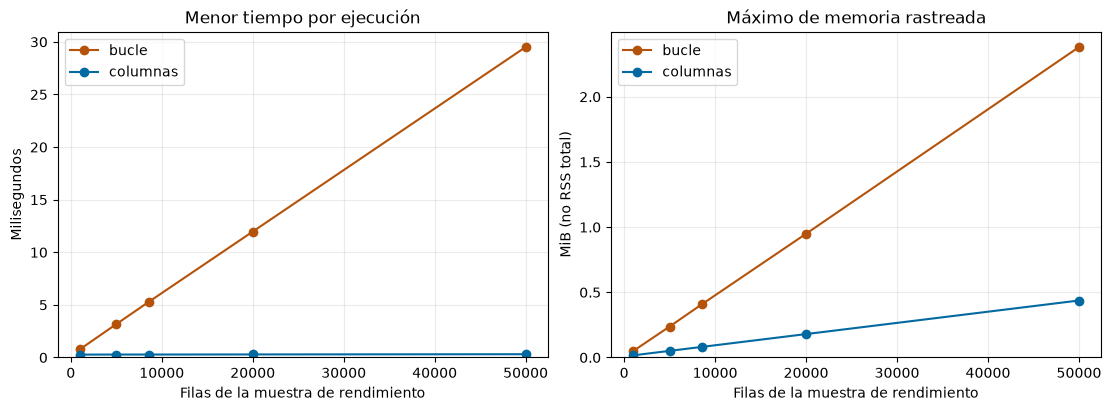

,tiempo_bucle_dividido_columnas,memoria_bucle_dividida_columnas
filas,,
1000,2.841,3.006
5000,11.308,4.670
8579,18.849,5.022
20000,41.156,5.284
50000,94.674,5.447


En la muestra de rendimiento de **8.579 filas**, el cociente de tiempos bucle/columnas fue **18.849**. Un valor mayor que 1 favorece a la resta por columnas; uno menor que 1 favorece al bucle.

,factor_tiempo_50000_sobre_1000,factor_memoria_50000_sobre_1000
algoritmo,,
bucle,37.886,47.873
columnas,1.137,26.415


Al multiplicar las filas por **50**, el tiempo del bucle se multiplicó por **37.89** y el de columnas por **1.14**. Comparamos esos factores con el crecimiento de memoria: las diferencias entre tiempos y asignaciones reflejan costos fijos y mecanismos distintos de ejecución. Estos cocientes describen el rango observado; la clasificación O(n) se justifica por los recorridos y por el tamaño de la salida.

In [13]:
fig, ejes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for algoritmo, color in [('bucle', '#b45309'), ('columnas', '#0369a1')]:
    datos = tabla_edades[tabla_edades['algoritmo'].eq(algoritmo)]
    ejes[0].plot(datos['filas'], datos['menor_ms'], marker='o', label=algoritmo, color=color)
    ejes[1].plot(datos['filas'], datos['maximo_rastreado_MiB'], marker='o', label=algoritmo, color=color)
ejes[0].set(title='Menor tiempo por ejecución', ylabel='Milisegundos')
ejes[1].set(title='Máximo de memoria rastreada', ylabel='MiB (no RSS total)')
for eje in ejes:
    eje.set_xlabel('Filas de la muestra de rendimiento')
    eje.set_ylim(bottom=0)
    eje.grid(alpha=0.25)
    eje.legend()
plt.show()
plt.close(fig)

tiempos = tabla_edades.pivot(index='filas', columns='algoritmo', values='menor_ms')
memorias = tabla_edades.pivot(index='filas', columns='algoritmo', values='maximo_rastreado_MiB')
razones = pd.DataFrame({'tiempo_bucle_dividido_columnas': tiempos['bucle'] / tiempos['columnas'],
                        'memoria_bucle_dividida_columnas': memorias['bucle'] / memorias['columnas']})
display(razones.round(3))
razon_real = float(razones.loc[8579, 'tiempo_bucle_dividido_columnas'])
display(Markdown(f'En la muestra de rendimiento de **8.579 filas**, el cociente de tiempos '
                 f'bucle/columnas fue **{razon_real:.3f}**. Un valor mayor que 1 favorece '
                 'a la resta por columnas; uno menor que 1 favorece al bucle.'))
crecimiento = pd.DataFrame({
    'factor_tiempo_50000_sobre_1000': tiempos.loc[50000] / tiempos.loc[1000],
    'factor_memoria_50000_sobre_1000': memorias.loc[50000] / memorias.loc[1000],
})
display(crecimiento.round(3))
display(Markdown(
    'Al multiplicar las filas por **50**, el tiempo del bucle se multiplicó por '
    f"**{crecimiento.loc['bucle', 'factor_tiempo_50000_sobre_1000']:.2f}** y el de columnas por "
    f"**{crecimiento.loc['columnas', 'factor_tiempo_50000_sobre_1000']:.2f}**. "
    'Comparamos esos factores con el crecimiento de memoria: las diferencias entre '
    'tiempos y asignaciones reflejan costos fijos y mecanismos distintos de ejecución. '
    'Estos cocientes describen el rango observado; la clasificación O(n) se justifica '
    'por los recorridos y por el tamaño de la salida.'
))

**Elección:** mantenemos la resta por columnas usada en F2. Expresa directamente
la operación y conserva `Int64`, el índice y las ausencias; la comparación
permite evaluar su costo sin cambiar el resultado. Si otro equipo obtiene una
ventaja menor o un resultado temporal distinto, se conserva y analiza esa
medición: no se exige que una alternativa gane en cada ejecución.

**Alcance del análisis:** esta complejidad corresponde a la derivada, no a todo
el notebook. El pipeline conserva varias copias e intermedios para trazabilidad,
con un costo de memoria real. Con columnas y vocabulario fijos, sus recorridos
por filas y la matriz de indicadores crecen con n; si el número de categorías
cambia, la matriz requiere espacio proporcional a filas por indicadores.
No extrapolamos estos benchmarks a medianas, carga completa o al flujo total.

<a id="lectura"></a>
## 12. Lectura completa y por columnas del SAV

Comparamos leer las 1.126 columnas del mismo SAV y seleccionar las 19 necesarias
frente a pedir esas 19 desde la lectura mediante `usecols`. Se comprueban valores,
tipos, índices, ausencias, orden y metadatos de las columnas seleccionadas.
Se conservan los códigos de faltantes SPSS antes de su limpieza.

Medimos lectura, selección/copia y extracción de metadatos. Excluimos descarga,
huellas, comprobación de igualdad, impresión y escritura. Las lecturas previas
calientan la caché: estos tiempos no representan una primera lectura en frío.
La memoria de salida puede coincidir aunque el máximo rastreado sea distinto.

La comparación responde a la observación de evitar cargar columnas innecesarias.
El flujo principal de este cuaderno continúa usando el CSV verificado de F2 para
mantener su contrato. El experimento demuestra una alternativa de lectura del
SAV; no afirmamos haber cambiado silenciosamente el origen del pipeline.

SAV verificado. Comparando valores y metadatos antes de medir...


,alternativa,menor_segundos,maximo_rastreado_MiB,tabla_devuelta_MiB
0,completo_y_seleccion,2.75553,671.40331,3.94244
1,solo_columnas,0.53519,13.14610,3.94244


,completo_y_seleccion,solo_columnas
repetición (desde 0),,
0,2.901726,0.535191
1,2.763176,0.536992
2,2.755529,0.569020
3,2.760612,0.536998
4,2.838148,0.586562


Metadatos comparados: column_names_to_labels, variable_value_labels, missing_ranges, original_variable_types, readstat_variable_types, variable_measure
Equivalencia: OK


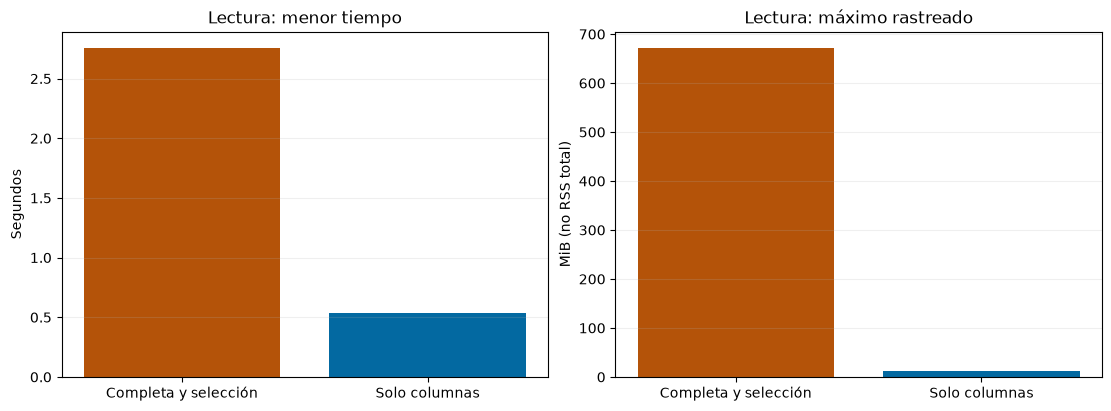

El cociente de tiempos lectura completa/solo columnas fue **5.149** en esta ejecución. Interpretamos la ventaja junto al máximo rastreado y a la igualdad de los resultados, no solo al tiempo.

El cociente de máximos rastreados fue **51.072**; ambas tablas devueltas ocuparon **3.942 MiB**. La diferencia se encuentra en el trabajo de lectura y sus temporales, aunque el producto final sea el mismo. Esta evidencia permite priorizar la lectura selectiva cuando se adopte una entrada directa desde el SAV.

In [14]:
medicion_sav = medir_lectura(REPETICIONES, EJECUCIONES_LECTURA)
tabla_sav = pd.DataFrame([
    {'alternativa': nombre, 'menor_segundos': valor['menor_segundos'],
     'maximo_rastreado_MiB': valor['maximo_rastreado_bytes'] / 2**20,
     'tabla_devuelta_MiB': valor['tabla_devuelta_bytes'] / 2**20}
    for nombre, valor in medicion_sav['resultados'].items()
])
display(tabla_sav.round(5))
display(pd.DataFrame({nombre: valor['segundos_por_ejecucion']
                      for nombre, valor in medicion_sav['resultados'].items()})
        .rename_axis('repetición (desde 0)'))
print('Metadatos comparados:', ', '.join(medicion_sav['metadatos_comparados']))
print('Equivalencia:', medicion_sav['equivalencia'])
fig, ejes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for eje, columna, titulo, unidad in [
    (ejes[0], 'menor_segundos', 'Lectura: menor tiempo', 'Segundos'),
    (ejes[1], 'maximo_rastreado_MiB', 'Lectura: máximo rastreado', 'MiB (no RSS total)'),
]:
    eje.bar(['Completa y selección', 'Solo columnas'], tabla_sav[columna],
            color=['#b45309', '#0369a1'])
    eje.set(title=titulo, ylabel=unidad)
    eje.grid(axis='y', alpha=0.2)
plt.show()
plt.close(fig)
sav_valores = tabla_sav.set_index('alternativa')
razon_sav = (sav_valores.loc['completo_y_seleccion', 'menor_segundos'] /
             sav_valores.loc['solo_columnas', 'menor_segundos'])
display(Markdown(f'El cociente de tiempos lectura completa/solo columnas fue **{razon_sav:.3f}** '
                 'en esta ejecución. Interpretamos la ventaja junto al máximo rastreado '
                 'y a la igualdad de los resultados, no solo al tiempo.'))
razon_memoria_sav = (sav_valores.loc['completo_y_seleccion', 'maximo_rastreado_MiB'] /
                     sav_valores.loc['solo_columnas', 'maximo_rastreado_MiB'])
assert (sav_valores['tabla_devuelta_MiB'].nunique() == 1)
display(Markdown(
    f'El cociente de máximos rastreados fue **{razon_memoria_sav:.3f}**; '
    f"ambas tablas devueltas ocuparon **{sav_valores['tabla_devuelta_MiB'].iloc[0]:.3f} MiB**. "
    'La diferencia se encuentra en el trabajo de lectura y sus temporales, aunque '
    'el producto final sea el mismo. Esta evidencia permite priorizar la lectura '
    'selectiva cuando se adopte una entrada directa desde el SAV.'
))

Al materializar una tabla completa se almacenan valores de n filas por p
columnas; al materializar k columnas se reduce ese componente a n por k.
Aquí p=1.126 y k=19. El tiempo de acceso al archivo depende también del formato,
su compresión y la biblioteca: no deducimos que los bytes leídos disminuyan
exactamente en la razón p/k ni asignamos al lector una complejidad no verificada.

**Balance del trabajo de eficiencia:** filtramos la población antes de limpiar,
reutilizamos intermedios en el flujo principal, contrastamos lectura selectiva y
conservamos la derivada por columnas. Las repeticiones y recargas deliberadas
de pruebas y benchmarks son evidencia de verificación, no operaciones que
deban repetirse durante cada análisis posterior.

<a id="exportacion"></a>
## 13. Exportación, relectura y contrato de entrega

Guardamos `enssex_convivientes_F3.csv`, `enssex_convivientes_F3_nominales.csv`
y `exportacion_F3.json` en `F3/data/processed`. El manifiesto conserva esquema,
tipos, orden de columnas, dimensiones y SHA-256 de cada CSV. La relectura restaura
categorías, enteros anulables, fechas e identificadores de texto. El índice de
filas se reconstruye como `RangeIndex`; el folio y el orden se conservan.

Los CSV no contienen por sí solos toda esa información de tipos: deben
acompañarse del manifiesto. Su integridad no autentica al manifiesto frente a
una modificación coordinada. No se incluyen las imputaciones simuladas.

Para repetir el notebook, comprobamos un conjunto existente completo. Si falta
alguno de los tres archivos o difiere el resultado, se detiene la ejecución;
se debe revisar el destino o elegir explícitamente otro en la configuración.

In [15]:
rutas_salida = [SALIDA_F3 / nombre for nombre in (*ARCHIVOS.values(), MANIFIESTO)]
existentes = [p.exists() for p in rutas_salida]
if any(existentes) and not all(existentes):
    raise FileExistsError('Exportación F3 incompleta: revisar el destino o elegir otra carpeta.')
if all(existentes):
    recuperadas = leer_resultados_f3(SALIDA_F3)
    manifiesto = json.loads((SALIDA_F3 / MANIFIESTO).read_text(encoding='utf-8'))
    assert manifiesto['esquema'] == esquema, 'El esquema guardado difiere del actual.'
    print('Productos existentes: verificación sin sobrescritura.')
else:
    manifiesto = exportar_resultados_f3(resultados, SALIDA_F3, esquema)
    recuperadas = leer_resultados_f3(SALIDA_F3)
    print('Productos F3 exportados y releídos.')
for nombre in ARCHIVOS:
    pd.testing.assert_frame_equal(resultados[nombre].reset_index(drop=True),
                                  recuperadas[nombre], check_exact=True)
assert manifiesto['comprobaciones_preexportacion'] == 130
display(pd.DataFrame([
    {'producto': nombre, 'archivo': ARCHIVOS[nombre], 'filas': detalle['filas'],
     'columnas': len(detalle['columnas']), 'sha256': detalle['sha256']}
    for nombre, detalle in manifiesto['productos'].items()
]))
print('OK: relectura exacta; F2 y los originales permanecen separados de la salida F3.')

Productos F3 exportados y releídos.


,producto,archivo,filas,columnas,sha256
0,principal,enssex_convivientes_F3.csv,8579,20,9af8b7f5f95289fdf1d632d60b384b5820013c659e1842...
1,nominales,enssex_convivientes_F3_nominales.csv,8579,65,8896ffa62fe569aed2d91f59560e88fff073ed23797908...


OK: relectura exacta; F2 y los originales permanecen separados de la salida F3.


**Contrato para la fase posterior:** la tabla principal contiene 8.579 personas,
19 variables originales preparadas y una diferencia de edad; la matriz auxiliar
contiene el folio y 64 indicadores nominales. Se entregan con el esquema del
manifiesto y el diccionario mostrado en la sección 5. `leer_resultados_f3()` es
la entrada prevista para recuperar tipos; no se deben volver a limpiar ni
codificar productos ya preparados.

La fase analítica deberá seleccionar denominadores por comparación, conservar
la interpretación ordinal, reconocer las limitaciones de las ausencias y
mantener el alcance muestral. No se entrega una duración de convivencia ni
respuestas inferidas mediante imputación. Los gráficos de este cuaderno
describen rendimiento computacional, no resultados sustantivos del estudio.

<a id="cierre"></a>
## 14. Verificación final y trazabilidad

La organización conserva `F1`, `F2` y `F3` diferenciadas. El notebook preliminar
de F1 permanece como antecedente histórico; este cuaderno integra el avance de
F3 y no reemplaza retroactivamente esas evidencias. El registro siguiente resume
cambios ya integrados en la base del proyecto, no atribuye a este notebook
publicaciones que todavía no se han realizado.

| Integración | Evidencia y decisión |
|---|---|
| [PR #1](https://github.com/gosoriozamora/mcdi500-grupo9-enssex/pull/1) | Retiro de la columna de convivencia vacía y corrección de documentación |
| [PR #2](https://github.com/gosoriozamora/mcdi500-grupo9-enssex/pull/2) | Huella del esquema normalizada entre equipos |
| [PR #3](https://github.com/gosoriozamora/mcdi500-grupo9-enssex/pull/3) y [#4](https://github.com/gosoriozamora/mcdi500-grupo9-enssex/pull/4) | Limpieza y categorías mediante clases, con revisión cruzada |
| [PR #5](https://github.com/gosoriozamora/mcdi500-grupo9-enssex/pull/5) | Estrategias descriptivas de faltantes |
| [PR #6](https://github.com/gosoriozamora/mcdi500-grupo9-enssex/pull/6) | Coordinación del pipeline y equivalencia con F2 |
| [PR #7](https://github.com/gosoriozamora/mcdi500-grupo9-enssex/pull/7) | Exportación y recuperación verificable |
| [PR #8](https://github.com/gosoriozamora/mcdi500-grupo9-enssex/pull/8) | Medición de lectura completa y por columnas |
| [PR #9](https://github.com/gosoriozamora/mcdi500-grupo9-enssex/pull/9) y [#10](https://github.com/gosoriozamora/mcdi500-grupo9-enssex/pull/10) | Equivalencia de algoritmos, tiempo, memoria y complejidad de la derivada |

Base de integración de esta edición: `8137fad`. Las huellas siguientes identifican
los archivos usados en esta ejecución con independencia de los finales de línea.
El entorno, protocolos y repeticiones completos se conservan en la salida JSON.
Los documentos publicados en `F3/docs` contienen las mediciones históricas;
los números recién calculados aquí corresponden a esta ejecución y no los reemplazan.

In [16]:
# Verificación de integridad después del flujo, pruebas, exportación y mediciones.
for relativa, huella in huellas_antes.items():
    assert prep.sha256_archivo(RAIZ / relativa) == huella, f'Archivo alterado: {relativa}'
pd.testing.assert_series_equal(pd.util.hash_pandas_object(base, index=True), huella_base)
pd.testing.assert_series_equal(base.dtypes, tipos_base)
pd.testing.assert_index_equal(base.columns, columnas_base)
pd.testing.assert_frame_equal(limpia, respaldo_limpia, check_exact=True)
for nombre, referencia in referencias_f2.items():
    pd.testing.assert_frame_equal(resultados[nombre], referencia, check_exact=True)

resumen_final = pd.DataFrame([
    {'verificación': 'Identidad de originales, módulos y productos F2', 'resultado': 'OK'},
    {'verificación': 'Entrada y tablas de preparación intactas', 'resultado': 'OK'},
    {'verificación': '8.579 personas, 20 columnas principales y 65 nominales', 'resultado': 'OK'},
    {'verificación': '883 códigos recodificados; cero imputaciones en el producto', 'resultado': 'OK'},
    {'verificación': '130 comprobaciones de resultados', 'resultado': 'OK'},
    {'verificación': 'Siete scripts de pruebas completos', 'resultado': 'OK'},
    {'verificación': '14 escenarios de faltantes separados del producto', 'resultado': 'OK'},
    {'verificación': 'Equivalencia previa a medir y muestras por tamaño', 'resultado': 'OK'},
    {'verificación': 'Exportación y relectura exacta', 'resultado': 'OK'},
])
assert len(tabla_pruebas) == 7 and tabla_pruebas['codigo_salida'].eq(0).all()
display(resumen_final)

archivos_codigo = [p for p in protegidos if p.suffix == '.py']
trazabilidad = {
    'inicio_utc': INICIO_UTC, 'fin_utc': datetime.now(timezone.utc).isoformat(),
    'base_integracion_documentada': '8137fad', 'entorno_kernel': entorno,
    'schema_sha256_lf': prep.sha256_codigo(ruta_esquema),
    'codigo_sha256_lf': {str(p.relative_to(RAIZ)): prep.sha256_codigo(p) for p in archivos_codigo},
    'pruebas': registros_pruebas, 'medicion_diferencia_edad': medicion_edades,
    'medicion_lectura_sav': medicion_sav,
    'productos': manifiesto['productos'],
    'archivos_protegidos_intactos': True,
}
# La salida queda guardada en el propio ipynb: no se sobrescribe evidencia histórica.
print(json.dumps(trazabilidad, ensure_ascii=False, indent=2, allow_nan=False))

,verificación,resultado
0,"Identidad de originales, módulos y productos F2",OK
1,Entrada y tablas de preparación intactas,OK
2,"8.579 personas, 20 columnas principales y 65 n...",OK
3,883 códigos recodificados; cero imputaciones e...,OK
4,130 comprobaciones de resultados,OK
5,Siete scripts de pruebas completos,OK
6,14 escenarios de faltantes separados del producto,OK
7,Equivalencia previa a medir y muestras por tamaño,OK
8,Exportación y relectura exacta,OK


{
  "inicio_utc": "2026-09-27T14:46:37.149778+00:00",
  "fin_utc": "2026-09-27T14:47:41.559266+00:00",
  "base_integracion_documentada": "8137fad",
  "entorno_kernel": {
    "python": "3.13.15",
    "sistema": "Windows",
    "arquitectura": "AMD64",
    "pandas": "3.0.5",
    "numpy": "2.5.3",
    "matplotlib": "3.11.2",
    "pyreadstat": "1.3.6",
    "ipykernel": "7.3.0",
    "jupyterlab": "4.6.3"
  },
  "schema_sha256_lf": "ba07debf0ff880bac775c64584a2fcb1c172ff7f88a13acea402df951fd3d2ad",
  "codigo_sha256_lf": {
    "F2\\src\\documentar_enssex.py": "6ea06f243ee0cb8cb8fe81ec766090cb832da3bd72cbe320ad6f6d682d4484ba",
    "F2\\src\\preparar_enssex.py": "7bd7bbd4818247cb0112c2f4bad39a539eadfd267475a0733e226a1252a33ffc",
    "F2\\src\\presentacion_enssex.py": "d9028a912e0cfa32c1bc510d81d3f41a22ae0a5b3d3381bd91b5df71708e02a0",
    "F2\\src\\visualizar_enssex.py": "a5ec693e67e478be84e46d7f92930fe301e388b4aba746c23a0a22fae2e55c18",
    "F3\\src\\diferencia_edad.py": "4c44c2baf8a1eed9d605c95

### Cierre técnico y alcance de la entrega

La ejecución integra módulos, POO, decisiones de preparación, casos de prueba,
comparaciones de eficiencia, análisis de complejidad y productos verificables.
Las salidas anteriores permiten revisar cada comprobación y repetirla en otro
equipo. El resultado conserva las reglas de F2 y su población seleccionada.

Quedan fuera del cierre de este cuaderno: su incorporación y revisión mediante
pull request, la actualización del README y la revisión final del informe
institucional. Tampoco corresponde afirmar representatividad nacional, causalidad
o una mejora de complejidad asintótica que los algoritmos no tienen.

<a id="referencias"></a>
## 15. Referencias

Las tres primeras entradas corresponden a material docente. Las referencias de
Python y pandas documentan herramientas; el artículo académico de 2022 respalda
la relevancia del problema dentro de los últimos cinco años. Las reglas de
ENSSEX se conservan en la documentación de fuente y el esquema del repositorio.

Guan, N., Guariglia, A., Moore, P., Xu, F., & Al-Janabi, H. (2022). Financial stress
and depression in adults: A systematic review. *PLOS ONE, 17*(2), e0264041.
https://doi.org/10.1371/journal.pone.0264041

Python Software Foundation. (s. f.-a). *timeit — Measure execution time of small
code snippets*. Python documentation. Recuperado el 27 de septiembre de 2026, de
https://docs.python.org/3/library/timeit.html

Python Software Foundation. (s. f.-b). *tracemalloc — Trace memory allocations*.
Python documentation. Recuperado el 27 de septiembre de 2026, de
https://docs.python.org/3/library/tracemalloc.html

The pandas development team. (s. f.-a). *Categorical data*. pandas documentation.
Recuperado el 27 de septiembre de 2026, de
https://pandas.pydata.org/docs/user_guide/categorical.html

The pandas development team. (s. f.-b). *Working with missing data*. pandas
documentation. Recuperado el 27 de septiembre de 2026, de
https://pandas.pydata.org/docs/user_guide/missing_data.html

Universidad Andrés Bello. (s. f.-a). *Evaluación Sumativa 2: Avance Fase 3*
[Instrucciones y rúbrica de MCDI500]. Material del aula virtual Canvas.

Universidad Andrés Bello. (s. f.-b). *S2_F3_NucleoAlgoritmico_Eficiencia_POO*
[Notebook docente, secciones de división funcional, POO, eficiencia y patrones].
En *Material didáctico Semana 2*.
https://github.com/magistercienciadatos/Material_Didactico_Semana2/blob/main/proyecto-grupoX-mcdi500/F3/S2_F3_NucleoAlgoritmico_Eficiencia_POO.ipynb

Universidad Andrés Bello. (s. f.-c). *Programación para Ciencia de Datos: Parte
Práctica de la Semana 2* [Notebook docente, secciones II y IV].
En *Material didáctico Semana 2*.
https://github.com/magistercienciadatos/Material_Didactico_Semana2/blob/main/2_Parte_Pr%C3%A1ctica/MCDI_Practica_Semana_2.ipynb

### Documentación del proyecto utilizada

- [Esquema y reglas de F2](../../F2/docs/esquema_variables_F2.json).
- [Diccionario procesado de F2](../../F2/docs/Diccionario_procesado_F2.md).
- [Tratamiento de faltantes](../docs/Tratamiento_faltantes.md).
- [Arquitectura del pipeline](../docs/Pipeline_ENSSEX.md).
- [Exportación F3](../docs/Exportacion_F3.md).
- [Medición de lectura SAV](../docs/Medicion_lectura_SAV.md).
- [Alternativas de diferencia de edad](../docs/Alternativas_diferencia_edad.md).
- [Complejidad de la diferencia de edad](../docs/Complejidad_diferencia_edad.md).

Estos enlaces relativos corresponden a la ubicación final del notebook dentro
de `F3/notebooks`. Las contribuciones y revisiones se consultan en los PR
referenciados; el informe final deberá mantener las mismas cifras y límites.